In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, mean_absolute_error
import pandas as pd
import numpy as np
import pickle
import os

df = pd.read_csv("../data/race_results.csv")
df = df.dropna(subset=["GridPosition", "Position", "Abbreviation", "TeamName", "Race"])
df = df[df["GridPosition"] > 0]
df["Position"] = df["Position"].astype(int)

# Encode all categorical columns
le_driver  = LabelEncoder()
le_team    = LabelEncoder()
le_circuit = LabelEncoder()

df["DriverEncoded"]  = le_driver.fit_transform(df["Abbreviation"])
df["TeamEncoded"]    = le_team.fit_transform(df["TeamName"])
df["CircuitEncoded"] = le_circuit.fit_transform(df["Race"])

print(f"Circuits: {list(le_circuit.classes_)}")

# Train with circuit as extra feature
X = df[["GridPosition", "DriverEncoded", "TeamEncoded", "CircuitEncoded"]]
y = df["Position"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test, predictions):.2f} positions")
print(f"Exact accuracy: {accuracy_score(y_test, predictions)*100:.1f}%")

# Save everything
os.makedirs("../model", exist_ok=True)
with open("../model/model.pkl", "wb") as f:    pickle.dump(model, f)
with open("../model/le_driver.pkl", "wb") as f:  pickle.dump(le_driver, f)
with open("../model/le_team.pkl", "wb") as f:    pickle.dump(le_team, f)
with open("../model/le_circuit.pkl", "wb") as f: pickle.dump(le_circuit, f)

# Save circuit and driver stats for the season stats tab
circuit_stats = df.groupby(["Race", "Abbreviation"])["Position"].mean().reset_index()
circuit_stats.columns = ["Race", "Driver", "AvgPosition"]
circuit_stats.to_csv("../data/circuit_stats.csv", index=False)

driver_stats = df.groupby("Abbreviation")["Position"].mean().reset_index()
driver_stats.columns = ["Driver", "AvgPosition"]
driver_stats = driver_stats.sort_values("AvgPosition")
driver_stats.to_csv("../data/driver_stats.csv", index=False)

print("\nAll files saved!")

Circuits: ['Abu Dhabi Grand Prix', 'Australian Grand Prix', 'Austrian Grand Prix', 'Azerbaijan Grand Prix', 'Bahrain Grand Prix', 'Belgian Grand Prix', 'British Grand Prix', 'Canadian Grand Prix', 'Chinese Grand Prix', 'Dutch Grand Prix', 'Emilia Romagna Grand Prix', 'French Grand Prix', 'Hungarian Grand Prix', 'Italian Grand Prix', 'Japanese Grand Prix', 'Las Vegas Grand Prix', 'Mexico City Grand Prix', 'Miami Grand Prix', 'Monaco Grand Prix', 'Portuguese Grand Prix', 'Qatar Grand Prix', 'Russian Grand Prix', 'Saudi Arabian Grand Prix', 'Singapore Grand Prix', 'Spanish Grand Prix', 'Styrian Grand Prix', 'São Paulo Grand Prix', 'Turkish Grand Prix', 'United States Grand Prix']
MAE: 3.62 positions
Exact accuracy: 12.5%

All files saved!


In [4]:
df = pd.read_csv("../data/race_results.csv")
print(df.columns.tolist())
print(df["Race"].unique())

['Abbreviation', 'TeamName', 'GridPosition', 'Position', 'Points', 'Year', 'Race']
['Bahrain Grand Prix' 'Emilia Romagna Grand Prix' 'Portuguese Grand Prix'
 'Spanish Grand Prix' 'Monaco Grand Prix' 'Azerbaijan Grand Prix'
 'French Grand Prix' 'Styrian Grand Prix' 'Austrian Grand Prix'
 'British Grand Prix' 'Hungarian Grand Prix' 'Belgian Grand Prix'
 'Dutch Grand Prix' 'Italian Grand Prix' 'Russian Grand Prix'
 'Turkish Grand Prix' 'United States Grand Prix' 'Mexico City Grand Prix'
 'São Paulo Grand Prix' 'Qatar Grand Prix' 'Saudi Arabian Grand Prix'
 'Abu Dhabi Grand Prix' 'Australian Grand Prix' 'Miami Grand Prix'
 'Canadian Grand Prix' 'Singapore Grand Prix' 'Japanese Grand Prix'
 'Chinese Grand Prix' 'Las Vegas Grand Prix']


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, mean_absolute_error
import pandas as pd
import numpy as np
import pickle
import os

# Load full dataset
df = pd.read_csv("../data/race_results.csv")

print(f"Total rows: {len(df)}")
print(f"Seasons: {sorted(df['Year'].unique())}")
print(f"Races: {df['Race'].nunique()}")

# Clean
df = df.dropna(subset=["GridPosition", "Position", "Abbreviation", "TeamName"])
df = df[df["GridPosition"] > 0]
df["Position"] = df["Position"].astype(int)

# Encode
le_driver = LabelEncoder()
le_team   = LabelEncoder()
df["DriverEncoded"] = le_driver.fit_transform(df["Abbreviation"])
df["TeamEncoded"]   = le_team.fit_transform(df["TeamName"])

print(f"\nDrivers in model: {list(le_driver.classes_)}")
print(f"Teams in model:   {list(le_team.classes_)}")

# Train
X = df[["GridPosition", "DriverEncoded", "TeamEncoded"]]
y = df["Position"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print(f"\nMAE: {mean_absolute_error(y_test, predictions):.2f} positions")
print(f"Exact accuracy: {accuracy_score(y_test, predictions)*100:.1f}%")

# Save
os.makedirs("../model", exist_ok=True)
with open("../model/model.pkl", "wb") as f: pickle.dump(model, f)
with open("../model/le_driver.pkl", "wb") as f: pickle.dump(le_driver, f)
with open("../model/le_team.pkl", "wb") as f: pickle.dump(le_team, f)

print("\nModel saved!")

Total rows: 1778
Seasons: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Races: 29

Drivers in model: ['ALB', 'ALO', 'ANT', 'BEA', 'BOR', 'BOT', 'COL', 'DEV', 'DOO', 'GAS', 'GIO', 'HAD', 'HAM', 'HUL', 'KUB', 'LAT', 'LAW', 'LEC', 'MAG', 'MAZ', 'MSC', 'NOR', 'OCO', 'PER', 'PIA', 'RAI', 'RIC', 'RUS', 'SAI', 'SAR', 'STR', 'TSU', 'VER', 'VET', 'ZHO']
Teams in model:   ['Alfa Romeo', 'Alfa Romeo Racing', 'AlphaTauri', 'Alpine', 'Aston Martin', 'Ferrari', 'Haas F1 Team', 'Kick Sauber', 'McLaren', 'Mercedes', 'RB', 'Racing Bulls', 'Red Bull Racing', 'Williams']

MAE: 3.67 positions
Exact accuracy: 17.7%

Model saved!


In [2]:
import fastf1
import pandas as pd
import time
import os
os.makedirs("../data/cache", exist_ok=True)
fastf1.Cache.enable_cache("../data/cache")

seasons = [2024, 2025]
new_results = []

for year in seasons:
    schedule = fastf1.get_event_schedule(year, include_testing=False)
    
    for _, event in schedule.iterrows():
        try:
            session = fastf1.get_session(year, event["EventName"], "R")
            session.load(telemetry=False, weather=False, messages=False)
            
            results = session.results[["Abbreviation", "TeamName", "GridPosition", "Position", "Points"]].copy()
            results["Year"] = year
            results["Race"] = event["EventName"]
            new_results.append(results)
            print(f"✅ {year} {event['EventName']}")
            
            time.sleep(2)  # avoid rate limit
            
        except Exception as e:
            print(f"❌ {year} {event['EventName']} — {e}")
            continue

# Combine with old data
old_df = pd.read_csv("../data/race_results.csv")
new_df = pd.concat(new_results, ignore_index=True)
full_df = pd.concat([old_df, new_df], ignore_index=True)
full_df.to_csv("../data/race_results.csv", index=False)
print(f"\nDone! Total rows: {len(full_df)}")

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No ca

✅ 2024 Bahrain Grand Prix


core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 

✅ 2024 Saudi Arabian Grand Prix


core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No

...

✅ 2025 Las Vegas Grand Prix


events      WARNING 	Correcting user input 'Qatar Grand Prix' to 'Qatar Grand Prix'
core           INFO 	Loading data for Qatar Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data.

✅ 2025 Qatar Grand Prix


core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No 

✅ 2025 Abu Dhabi Grand Prix

Done! Total rows: 1778


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, mean_absolute_error
import pickle

# Load data
df = pd.read_csv("../data/race_results.csv")

# Drop rows with missing values
df = df.dropna(subset=["GridPosition", "Position", "Abbreviation", "TeamName"])

# Remove rows where grid position is 0 (pit lane starts, rare edge case)
df = df[df["GridPosition"] > 0]

# Encode categorical columns
le_driver = LabelEncoder()
le_team = LabelEncoder()

df["DriverEncoded"] = le_driver.fit_transform(df["Abbreviation"])
df["TeamEncoded"] = le_team.fit_transform(df["TeamName"])

# Features and target
X = df[["GridPosition", "DriverEncoded", "TeamEncoded"]]
y = df["Position"].astype(int)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Evaluate
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
acc = accuracy_score(y_test, predictions)

print(f"Mean Absolute Error: {mae:.2f} positions")
print(f"Exact accuracy: {acc*100:.1f}%")

# Save model and encoders
import pickle, os
os.makedirs("../model", exist_ok=True)

with open("../model/model.pkl", "wb") as f:
    pickle.dump(model, f)
with open("../model/le_driver.pkl", "wb") as f:
    pickle.dump(le_driver, f)
with open("../model/le_team.pkl", "wb") as f:
    pickle.dump(le_team, f)

print("\nModel saved!")
print("Drivers the model knows:", list(le_driver.classes_))

Mean Absolute Error: 3.84 positions
Exact accuracy: 13.8%

Model saved!
Drivers the model knows: ['ALB', 'ALO', 'BOT', 'DEV', 'GAS', 'GIO', 'HAM', 'HUL', 'KUB', 'LAT', 'LEC', 'MAG', 'MAZ', 'MSC', 'NOR', 'OCO', 'PER', 'PIA', 'RAI', 'RIC', 'RUS', 'SAI', 'SAR', 'STR', 'TSU', 'VER', 'VET', 'ZHO']


In [6]:
df = pd.read_csv("../data/race_results.csv")
print(f"Total rows: {len(df)}")
print(f"Seasons: {df['Year'].unique()}")
print(f"Races: {df['Race'].nunique()}")
print(df.head())

Total rows: 820
Seasons: [2021 2022 2023]
Races: 27
  Abbreviation         TeamName  GridPosition  Position  Points  Year  \
0          HAM         Mercedes           2.0       1.0    25.0  2021   
1          VER  Red Bull Racing           1.0       2.0    18.0  2021   
2          BOT         Mercedes           3.0       3.0    16.0  2021   
3          NOR          McLaren           7.0       4.0    12.0  2021   
4          PER  Red Bull Racing           0.0       5.0    10.0  2021   

                 Race  
0  Bahrain Grand Prix  
1  Bahrain Grand Prix  
2  Bahrain Grand Prix  
3  Bahrain Grand Prix  
4  Bahrain Grand Prix  


In [5]:
seasons = [2021, 2022, 2023]
all_results = []

for year in seasons:
    schedule = fastf1.get_event_schedule(year, include_testing=False)
    
    for _, event in schedule.iterrows():
        try:
            session = fastf1.get_session(year, event["EventName"], "R")
            session.load(telemetry=False, weather=False, messages=False)
            
            results = session.results[["Abbreviation", "TeamName", "GridPosition", "Position", "Points"]].copy()
            results["Year"] = year
            results["Race"] = event["EventName"]
            all_results.append(results)
            print(f"✅ {year} {event['EventName']}")
            
        except Exception as e:
            print(f"❌ {year} {event['EventName']} — {e}")
            continue

df = pd.concat(all_results, ignore_index=True)
df.to_csv("../data/race_results.csv", index=False)
print(f"\nDone! {len(df)} rows saved.")

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No ca

✅ 2021 Bahrain Grand Prix


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

✅ 2021 Emilia Romagna Grand Prix


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
_api        WARNING 	Driver 44: Ignoring late data f

...

❌ 2023 São Paulo Grand Prix — any API: 500 calls/h


Request for URL https://raw.githubusercontent.com/theOehrly/f1schedule/master/schedule_2023.json failed; using cached response
Traceback (most recent call last):
  File "c:\Users\Bhavya\f1-predictor\.venv\Lib\site-packages\requests_cache\session.py", line 311, in _resend
    response = self._send_and_cache(request, actions, cached_response, **kwargs)
  File "c:\Users\Bhavya\f1-predictor\.venv\Lib\site-packages\requests_cache\session.py", line 279, in _send_and_cache
    response = super().send(request, **kwargs)
  File "c:\Users\Bhavya\f1-predictor\.venv\Lib\site-packages\fastf1\req.py", line 110, in send
    lim.limit()
    ~~~~~~~~~^^
  File "c:\Users\Bhavya\f1-predictor\.venv\Lib\site-packages\fastf1\req.py", line 80, in limit
    raise RateLimitExceededError(self._info)
fastf1.exceptions.RateLimitExceededError: any API: 500 calls/h
core           INFO 	Loading data for Las Vegas Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_

❌ 2023 Las Vegas Grand Prix — any API: 500 calls/h


Request for URL https://raw.githubusercontent.com/theOehrly/f1schedule/master/schedule_2023.json failed; using cached response
Traceback (most recent call last):
  File "c:\Users\Bhavya\f1-predictor\.venv\Lib\site-packages\requests_cache\session.py", line 311, in _resend
    response = self._send_and_cache(request, actions, cached_response, **kwargs)
  File "c:\Users\Bhavya\f1-predictor\.venv\Lib\site-packages\requests_cache\session.py", line 279, in _send_and_cache
    response = super().send(request, **kwargs)
  File "c:\Users\Bhavya\f1-predictor\.venv\Lib\site-packages\fastf1\req.py", line 110, in send
    lim.limit()
    ~~~~~~~~~^^
  File "c:\Users\Bhavya\f1-predictor\.venv\Lib\site-packages\fastf1\req.py", line 80, in limit
    raise RateLimitExceededError(self._info)
fastf1.exceptions.RateLimitExceededError: any API: 500 calls/h
core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_

❌ 2023 Abu Dhabi Grand Prix — any API: 500 calls/h

Done! 820 rows saved.


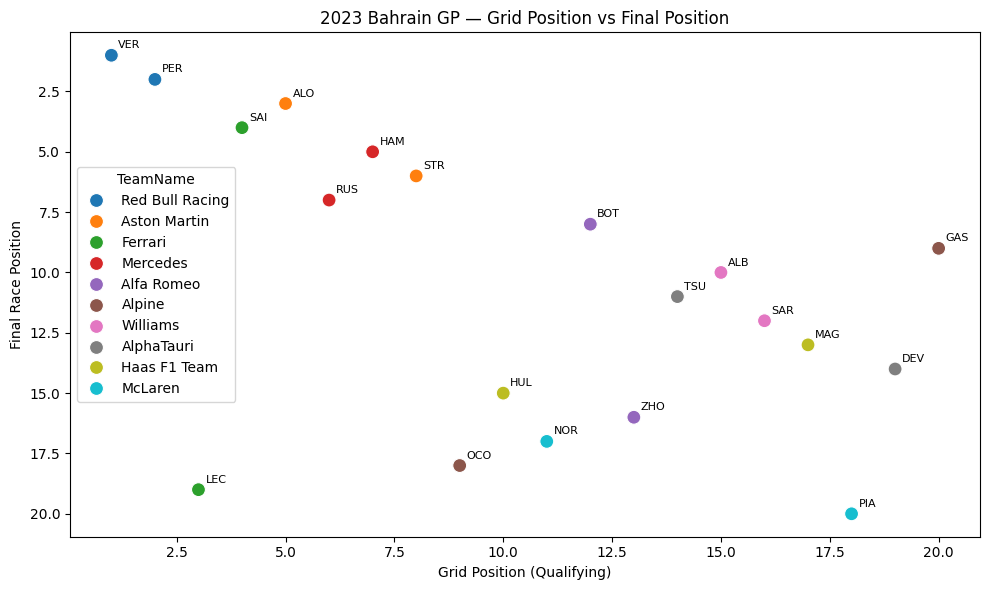

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot grid position vs final position
plt.figure(figsize=(10, 6))
sns.scatterplot(data=results, x="GridPosition", y="Position", hue="TeamName", s=100)

# Add driver labels
for _, row in results.iterrows():
    plt.annotate(row["Abbreviation"], (row["GridPosition"], row["Position"]), 
                 textcoords="offset points", xytext=(5, 5), fontsize=8)

plt.title("2023 Bahrain GP — Grid Position vs Final Position")
plt.xlabel("Grid Position (Qualifying)")
plt.ylabel("Final Race Position")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [3]:
# Final classification — who finished where
results = session.results
print(results[["DriverNumber", "Abbreviation", "TeamName", "GridPosition", "Position", "Points"]].to_string())

   DriverNumber Abbreviation         TeamName  GridPosition  Position  Points
1             1          VER  Red Bull Racing           1.0       1.0    25.0
11           11          PER  Red Bull Racing           2.0       2.0    18.0
14           14          ALO     Aston Martin           5.0       3.0    15.0
55           55          SAI          Ferrari           4.0       4.0    12.0
44           44          HAM         Mercedes           7.0       5.0    10.0
18           18          STR     Aston Martin           8.0       6.0     8.0
63           63          RUS         Mercedes           6.0       7.0     6.0
77           77          BOT       Alfa Romeo          12.0       8.0     4.0
10           10          GAS           Alpine          20.0       9.0     2.0
23           23          ALB         Williams          15.0      10.0     1.0
22           22          TSU       AlphaTauri          14.0      11.0     0.0
2             2          SAR         Williams          16.0     

In [2]:
# See all columns available to us
print(laps.columns.tolist())

['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']


In [1]:
import fastf1
import pandas as pd

fastf1.Cache.enable_cache("data/cache")

# Load a race session
session = fastf1.get_session(2023, "Bahrain", "R")
session.load()

# Get lap data
laps = session.laps
print(laps.head())

# Get specific driver laps
verstappen = laps.pick_drivers("VER")
print(verstappen[["LapNumber", "LapTime", "Compound", "TyreLife"]])

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '14', '55', '44', '18', '63', '77', '10', '23', '22', '2', '20', '21', '27', '24', '4', '31', '16', '81']


                    Time Driver DriverNumber                LapTime  \
0 0 days 01:04:15.902000    VER            1 0 days 00:01:39.019000   
1 0 days 01:05:53.876000    VER            1 0 days 00:01:37.974000   
2 0 days 01:07:31.882000    VER            1 0 days 00:01:38.006000   
3 0 days 01:09:09.858000    VER            1 0 days 00:01:37.976000   
4 0 days 01:10:47.893000    VER            1 0 days 00:01:38.035000   

   LapNumber  Stint PitOutTime PitInTime            Sector1Time  \
0        1.0    1.0        NaT       NaT                    NaT   
1        2.0    1.0        NaT       NaT 0 days 00:00:31.342000   
2        3.0    1.0        NaT       NaT 0 days 00:00:31.388000   
3        4.0    1.0        NaT       NaT 0 days 00:00:31.271000   
4        5.0    1.0        NaT       NaT 0 days 00:00:31.244000   

             Sector2Time  ... FreshTyre             Team  \
0 0 days 00:00:42.414000  ...     False  Red Bull Racing   
1 0 days 00:00:42.504000  ...     False  Red Bull 

In [9]:
import os
import fastf1
import pandas as pd

cache_dir = "data/cache"
os.makedirs(cache_dir, exist_ok=True)

fastf1.Cache.enable_cache(cache_dir)